# NBA Playoff Competitiveness: Efficiency Differential vs. Seeding
**Herbert Ouma | M.S. Data Science, University of St. Thomas | May 2026**

---

## Question
> *Does a team's regular-season efficiency differential (ORtg − DRtg) predict playoff series competitiveness better than seeding alone?*

## Hypotheses
- **H₀:** Regular-season efficiency differential between two playoff opponents has no stronger association with series competitiveness (games played) than seeding differential.
- **H₁:** Efficiency differential is a significantly stronger predictor — teams closer in net rating produce longer, more competitive series regardless of seed.

## Why It Matters — The 2026 Playoffs
| Series | Net Rtg Gap | Seed Gap | Result |
|--------|------------|----------|--------|
| OKC vs LAL | **8.9 pts** | 3 seeds | Near sweep (3-0) |
| SAS vs MIN | **4.2 pts** | 4 seeds | Dead-even (2-2) |
| DET vs CLE | **5.2 pts** | 3 seeds | Competitive (2-1) |
| NYK vs PHI | **4.4 pts** | 4 seeds | Swept (4-0) |

---
## 1. Setup & Imports

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

NBA_BLUE = 'blue'
NBA_RED  = 'red'
NBA_GREY = 'grey'

print('Libraries loaded')

Libraries loaded


---
## 2. Data

### 2.1 Sources
| File | Dataset | Used For |
|------|---------|----------|
| `Team Summaries.csv` | [NBA Stats 1947–present](https://www.kaggle.com/datasets/sumitrodatta/nba-aba-baa-stats) | ORtg, DRtg, Net Rating per team per season |
| `game.csv` | [NBA Database](https://www.kaggle.com/datasets/wyattowalsh/basketball) | Game results → playoff series outcomes |

Place both CSVs in the `data/` folder before running.

### 2.2 Key Engineering Decisions
- **Season offset:** `game.csv` uses season-start year (2022 = 2022-23); `Team Summaries.csv` uses season-end year (2023 = 2022-23). Applied `+1` on merge.
- **Abbreviation fixes:** `BKN→BRK`, `CHA→CHO`, `PHX→PHO`
- **Seed derivation:** No seed column in source data — derived by ranking playoff teams within conference by regular-season wins.
- **Series construction:** Built from game-level data: group by season + matchup, count games, determine winner by majority wins.

---
## 3. Data Loading & Cleaning

In [40]:
game_df = pd.read_csv('data/game.csv')
ts_df   = pd.read_csv('data/Team Summaries.csv')

print(f'game.csv:        {game_df.shape[0]:,} rows x {game_df.shape[1]} cols')
print(f'Team Summaries:  {ts_df.shape[0]:,} rows x {ts_df.shape[1]} cols')
print(f'Season types:    {game_df["season_type"].unique()}')

game.csv:        65,698 rows x 55 cols
Team Summaries:  1,907 rows x 31 cols
Season types:    ['Regular Season' 'Playoffs' 'All-Star' 'All Star' 'Pre Season']


In [41]:
# Step 1: Filter playoff games (2015-2022) and fix abbreviations
playoffs = game_df[game_df['season_type'] == 'Playoffs'].copy()
playoffs['season'] = playoffs['season_id'].astype(str).str[1:].astype(int)
playoffs = playoffs[playoffs['season'].between(2015, 2022)]

abbrev_map = {'BKN': 'BRK', 'CHA': 'CHO', 'PHX': 'PHO'}
playoffs['team_abbreviation_home'] = playoffs['team_abbreviation_home'].replace(abbrev_map)
playoffs['team_abbreviation_away'] = playoffs['team_abbreviation_away'].replace(abbrev_map)

print(f'Playoff games (2015-2022): {len(playoffs)}')
print(f'Seasons: {sorted(playoffs["season"].unique())}')

Playoff games (2015-2022): 668
Seasons: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


In [42]:
# Step 2: Build series-level results from game-level data
playoffs['team_a'] = playoffs[['team_abbreviation_home', 'team_abbreviation_away']].min(axis=1)
playoffs['team_b'] = playoffs[['team_abbreviation_home', 'team_abbreviation_away']].max(axis=1)
playoffs['series_key'] = (
    playoffs['season'].astype(str) + '_' + playoffs['team_a'] + '_' + playoffs['team_b'])

games_per_series = playoffs.groupby('series_key').size().reset_index(name='games_played')

def get_winner_loser(grp):
    home_wins = grp.loc[grp['wl_home'] == 'W', 'team_abbreviation_home'].tolist()
    away_wins = grp.loc[grp['wl_away'] == 'W', 'team_abbreviation_away'].tolist()
    all_winners = home_wins + away_wins
    winner = pd.Series(all_winners).value_counts().idxmax()

    if grp['team_a'].iloc[0] == winner:
        loser = grp['team_b'].iloc[0]
    else:
        loser = grp['team_a'].iloc[0]

    return pd.Series({'season': grp['season'].iloc[0], 'winner': winner, 'loser': loser})

series = playoffs.groupby('series_key').apply(get_winner_loser).reset_index()
series = series.merge(games_per_series, on='series_key')
series['ts_season'] = series['season'] + 1  # season offset

print(f'Series constructed: {len(series)}')
print('Null check:', series[['winner','loser','games_played']].isnull().sum().to_dict())
print('\nGames played distribution:')
print(series['games_played'].value_counts().sort_index())

Series constructed: 120
Null check: {'winner': 0, 'loser': 0, 'games_played': 0}

Games played distribution:
games_played
4    22
5    35
6    36
7    27
Name: count, dtype: int64


In [43]:
# Step 3: Derive seeds by ranking playoff teams within conference by wins
CONF_MAP = {
    'ATL':'E','BOS':'E','BRK':'E','CHO':'E','CHI':'E','CLE':'E','DET':'E',
    'IND':'E','MIA':'E','MIL':'E','NYK':'E','ORL':'E','PHI':'E','TOR':'E','WAS':'E',
    'DAL':'W','DEN':'W','GSW':'W','HOU':'W','LAC':'W','LAL':'W','MEM':'W',
    'MIN':'W','NOP':'W','OKC':'W','PHO':'W','POR':'W','SAC':'W','SAS':'W','UTA':'W'
}

ts_mod = ts_df[
    (ts_df['season'].between(2016, 2023)) &
    (ts_df['playoffs'] == True) &
    (ts_df['lg'] == 'NBA')
].copy()

ts_mod['conf'] = ts_mod['abbreviation'].map(CONF_MAP)
ts_mod['seed'] = (
    ts_mod.groupby(['season', 'conf'])['w']
    .rank(ascending=False, method='first')
    .astype(int)
)

print(f'Teams with ratings: {len(ts_mod)}')
print('Sample (East 2023):')
print(ts_mod[ts_mod['season']==2023][['abbreviation','conf','w','seed']]
      .sort_values(['conf','seed']).head(8).to_string())

Teams with ratings: 128
Sample (East 2023):
    abbreviation conf     w  seed
109          MIL    E  58.0     1
94           BOS    E  57.0     2
115          PHI    E  54.0     3
98           CLE    E  51.0     4
112          NYK    E  47.0     5
95           BRK    E  45.0     6
108          MIA    E  44.0     7
93           ATL    E  41.0     8


In [44]:
# Step 4: Merge ratings onto series + engineer key features

# Build winner ratings table
winner_ratings = ts_mod[['season', 'abbreviation', 'n_rtg', 'seed']].copy()
winner_ratings = winner_ratings.rename(columns={
    'abbreviation': 'winner',
    'n_rtg': 'winner_net',
    'seed': 'winner_seed',
    'season': 'merge_season'
})
df = series.merge(winner_ratings, left_on=['ts_season', 'winner'],
                  right_on=['merge_season', 'winner'], how='left')
df = df.drop(columns='merge_season')

# Build loser ratings table
loser_ratings = ts_mod[['season', 'abbreviation', 'n_rtg', 'seed']].copy()
loser_ratings = loser_ratings.rename(columns={
    'abbreviation': 'loser',
    'n_rtg': 'loser_net',
    'seed': 'loser_seed',
    'season': 'merge_season'
})
df = df.merge(loser_ratings, left_on=['ts_season', 'loser'],
              right_on=['merge_season', 'loser'], how='left')
df = df.drop(columns='merge_season')

df['net_rtg_gap'] = (df['winner_net'] - df['loser_net']).abs()
df['seed_gap']    = (df['winner_seed'] - df['loser_seed']).abs()
df['avg_net_rtg'] = (df['winner_net'] + df['loser_net']) / 2
df = df.dropna(subset=['net_rtg_gap', 'seed_gap', 'games_played'])

print(f'Final dataset: {len(df)} series across {df["season"].nunique()} seasons')
df[['season','winner','loser','games_played',
    'winner_net','loser_net','net_rtg_gap',
    'winner_seed','loser_seed','seed_gap']].head(8)

Final dataset: 120 series across 8 seasons


,season,winner,loser,games_played,winner_net,loser_net,net_rtg_gap,winner_seed,loser_seed,seed_gap
0,2015,ATL,BOS,6,3.7,3.2,0.5,3,4,1
1,2015,CLE,ATL,4,6.4,3.7,2.7,1,3,2
2,2015,MIA,CHO,7,1.7,2.9,1.2,6,5,1
3,2015,CLE,DET,4,6.4,0.6,5.8,1,8,7
4,2015,CLE,GSW,7,6.4,10.7,4.3,1,1,0
5,2015,CLE,TOR,6,6.4,4.8,1.6,1,2,1
6,2015,OKC,DAL,5,7.5,-0.3,7.8,3,6,3
7,2015,GSW,HOU,5,10.7,0.2,10.5,1,8,7


---
## 4. Exploratory Data Analysis

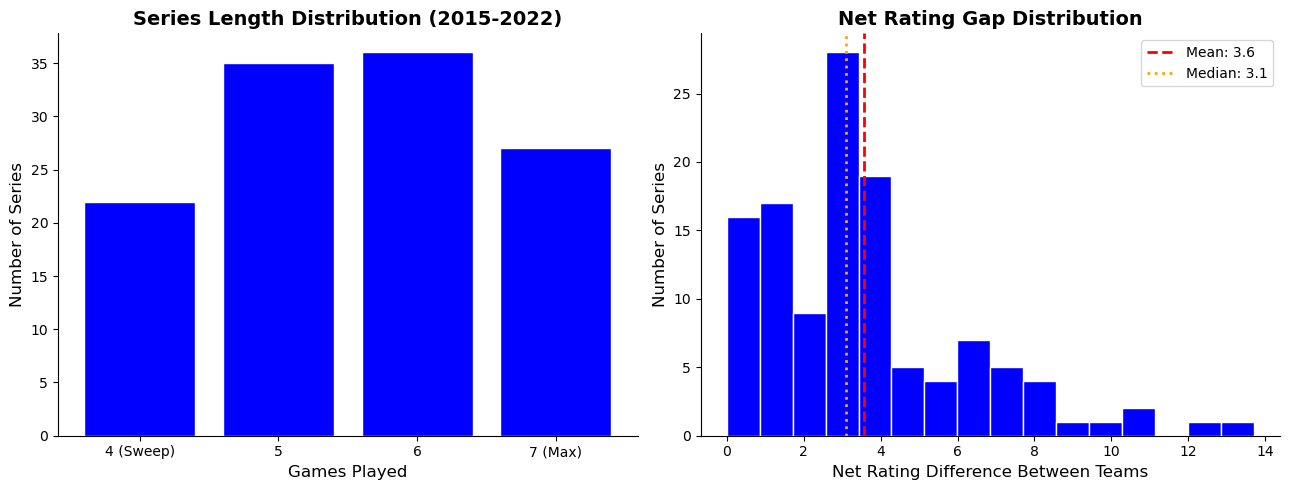

Sweep rate:  18.3%
7-game rate: 22.5%


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['games_played'].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=NBA_BLUE, edgecolor='white')
axes[0].set_title('Series Length Distribution (2015-2022)', fontweight='bold')
axes[0].set_xlabel('Games Played')
axes[0].set_ylabel('Number of Series')
axes[0].set_xticks([4, 5, 6, 7])
axes[0].set_xticklabels(['4 (Sweep)', '5', '6', '7 (Max)'])

axes[1].hist(df['net_rtg_gap'], bins=16, color=NBA_BLUE, edgecolor='white')
axes[1].axvline(df['net_rtg_gap'].mean(), color=NBA_RED, linewidth=2, linestyle='--',
                label=f"Mean: {df['net_rtg_gap'].mean():.1f}")
axes[1].axvline(df['net_rtg_gap'].median(), color='orange', linewidth=2, linestyle=':',
                label=f"Median: {df['net_rtg_gap'].median():.1f}")
axes[1].set_title('Net Rating Gap Distribution', fontweight='bold')
axes[1].set_xlabel('Net Rating Difference Between Teams')
axes[1].set_ylabel('Number of Series')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Sweep rate:  {(df["games_played"]==4).mean():.1%}')
print(f'7-game rate: {(df["games_played"]==7).mean():.1%}')

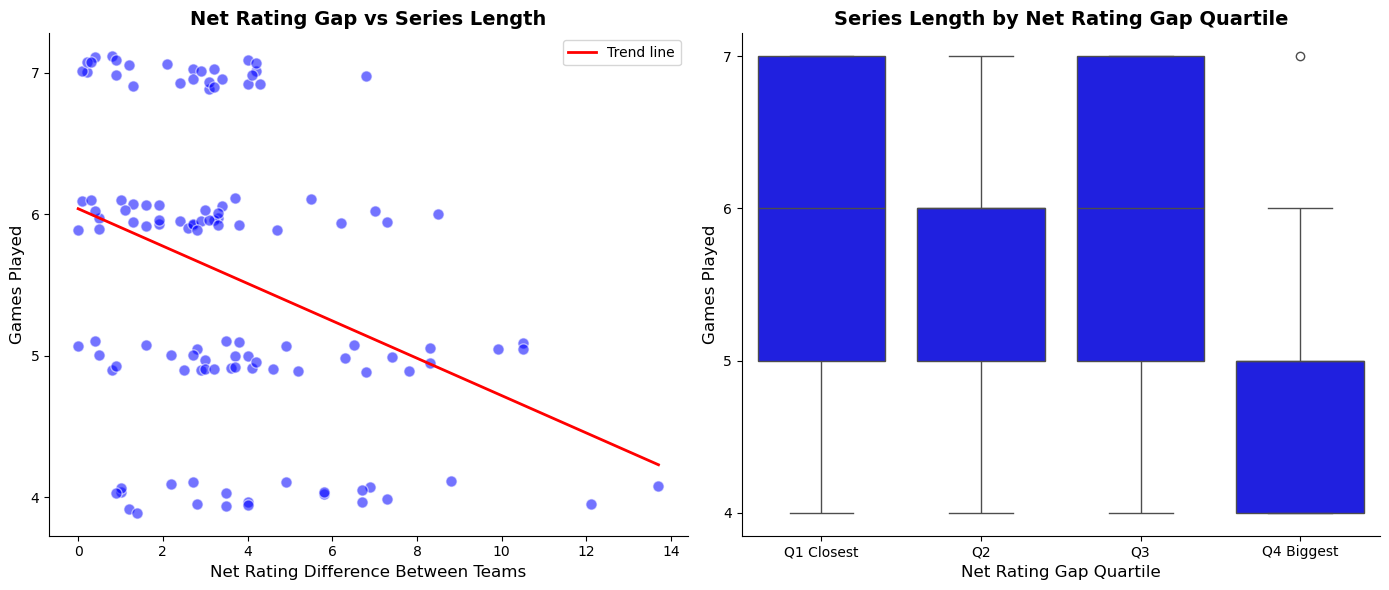

Pearson r (net rating gap vs games): r=-0.346  p=0.0001


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
np.random.seed(42)
jitter = np.random.uniform(-0.12, 0.12, len(df))

axes[0].scatter(df['net_rtg_gap'], df['games_played'] + jitter,
                alpha=0.55, color=NBA_BLUE, edgecolors='white', s=65)
z = np.polyfit(df['net_rtg_gap'], df['games_played'], 1)
xl = np.linspace(df['net_rtg_gap'].min(), df['net_rtg_gap'].max(), 100)
axes[0].plot(xl, z[0] * xl + z[1], color=NBA_RED, linewidth=2, label='Trend line')
axes[0].set_title('Net Rating Gap vs Series Length', fontweight='bold')
axes[0].set_xlabel('Net Rating Difference Between Teams')
axes[0].set_ylabel('Games Played')
axes[0].set_yticks([4, 5, 6, 7])
axes[0].legend()

df['gap_q'] = pd.qcut(df['net_rtg_gap'], q=4, labels=['Q1 Closest', 'Q2', 'Q3', 'Q4 Biggest'])
sns.boxplot(data=df, x='gap_q', y='games_played', ax=axes[1], color=NBA_BLUE)
axes[1].set_title('Series Length by Net Rating Gap Quartile', fontweight='bold')
axes[1].set_xlabel('Net Rating Gap Quartile')
axes[1].set_ylabel('Games Played')
axes[1].set_yticks([4, 5, 6, 7])

plt.tight_layout()
plt.show()

r_net, p_net = stats.pearsonr(df['net_rtg_gap'], df['games_played'])
print(f'Pearson r (net rating gap vs games): r={r_net:.3f}  p={p_net:.4f}')

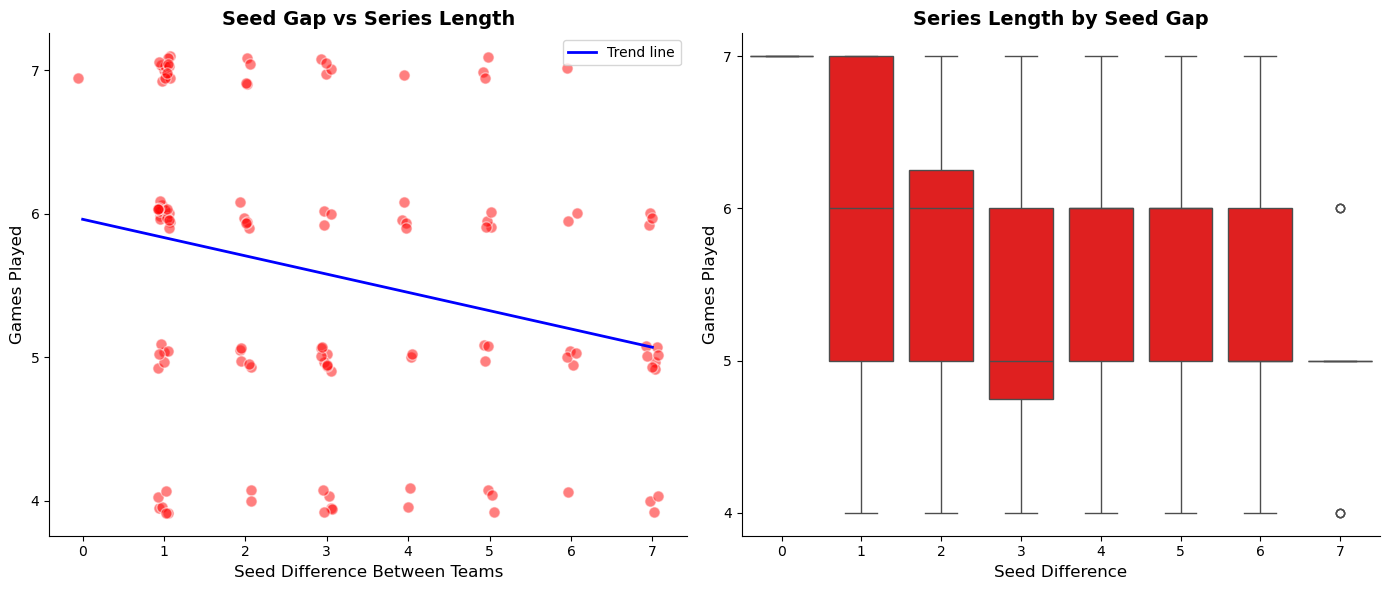

Pearson r (seed gap vs games): r=-0.258  p=0.0044


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
np.random.seed(42)
jx = np.random.uniform(-0.08, 0.08, len(df))
jy = np.random.uniform(-0.10, 0.10, len(df))

axes[0].scatter(df['seed_gap'] + jx, df['games_played'] + jy,
                alpha=0.5, color=NBA_RED, edgecolors='white', s=65)
z2 = np.polyfit(df['seed_gap'], df['games_played'], 1)
xl2 = np.linspace(df['seed_gap'].min(), df['seed_gap'].max(), 100)
axes[0].plot(xl2, z2[0] * xl2 + z2[1], color=NBA_BLUE, linewidth=2, label='Trend line')
axes[0].set_title('Seed Gap vs Series Length', fontweight='bold')
axes[0].set_xlabel('Seed Difference Between Teams')
axes[0].set_ylabel('Games Played')
axes[0].set_yticks([4, 5, 6, 7])
axes[0].legend()

sns.boxplot(data=df, x='seed_gap', y='games_played', ax=axes[1], color=NBA_RED)
axes[1].set_title('Series Length by Seed Gap', fontweight='bold')
axes[1].set_xlabel('Seed Difference')
axes[1].set_ylabel('Games Played')
axes[1].set_yticks([4, 5, 6, 7])

plt.tight_layout()
plt.show()

r_seed, p_seed = stats.pearsonr(df['seed_gap'], df['games_played'])
print(f'Pearson r (seed gap vs games): r={r_seed:.3f}  p={p_seed:.4f}')

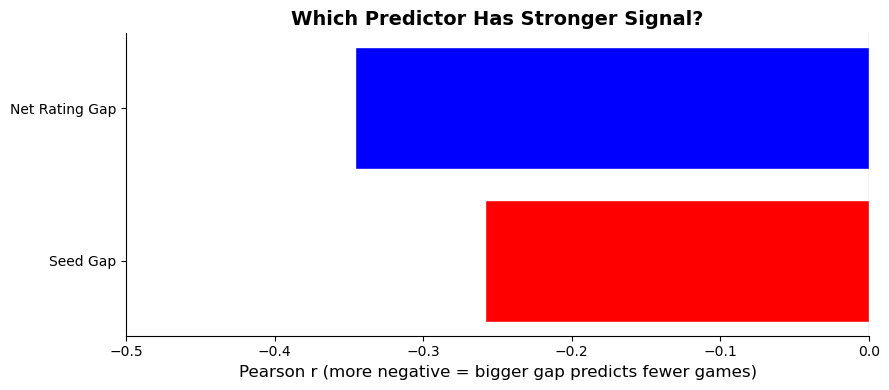

Net Rating Gap  r = -0.346
Seed Gap        r = -0.258
Difference in |r| = 0.088


In [48]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = ['Seed Gap', 'Net Rating Gap']
r_vals = [r_seed, r_net]
ax.barh(labels, r_vals, color=[NBA_RED, NBA_BLUE], edgecolor='white')
ax.set_xlim(-0.5, 0)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Which Predictor Has Stronger Signal?', fontweight='bold')
ax.set_xlabel('Pearson r (more negative = bigger gap predicts fewer games)')
plt.tight_layout()
plt.show()

print(f'Net Rating Gap  r = {r_net:.3f}')
print(f'Seed Gap        r = {r_seed:.3f}')
print(f'Difference in |r| = {abs(r_net) - abs(r_seed):.3f}')

---
## 5. Statistical Hypothesis Tests

### 5.1 Permutation Test

**Test statistic:** `Delta r = |r(net_rtg_gap, games)| - |r(seed_gap, games)|`

**H0:** Both predictors carry equal signal. Any observed Delta r is due to chance.

**Procedure:** Shuffle `net_rtg_gap` 10,000 times, recompute Delta r each time.

In [49]:
np.random.seed(42)
N_PERMS = 10_000
observed_delta = abs(r_net) - abs(r_seed)

games     = df['games_played'].values
net_gaps  = df['net_rtg_gap'].values
seed_gaps = df['seed_gap'].values

perm_deltas = []
for i in range(N_PERMS):
    shuffled = np.random.permutation(net_gaps)
    r_perm, _ = stats.pearsonr(shuffled, games)
    perm_deltas.append(abs(r_perm) - abs(r_seed))

perm_deltas = np.array(perm_deltas)
p_value = np.mean(perm_deltas >= observed_delta)

print(f'Observed delta r:         {observed_delta:.4f}')
print(f'Permutation p-value:      {p_value:.4f}')
print(f'95th percentile of nulls: {np.percentile(perm_deltas, 95):.4f}')
print(f'Reject H0 (alpha=0.05)?   {"YES" if p_value < 0.05 else "NO"}')

Observed delta r:         0.0878
Permutation p-value:      0.0001
95th percentile of nulls: -0.0758
Reject H0 (alpha=0.05)?   YES


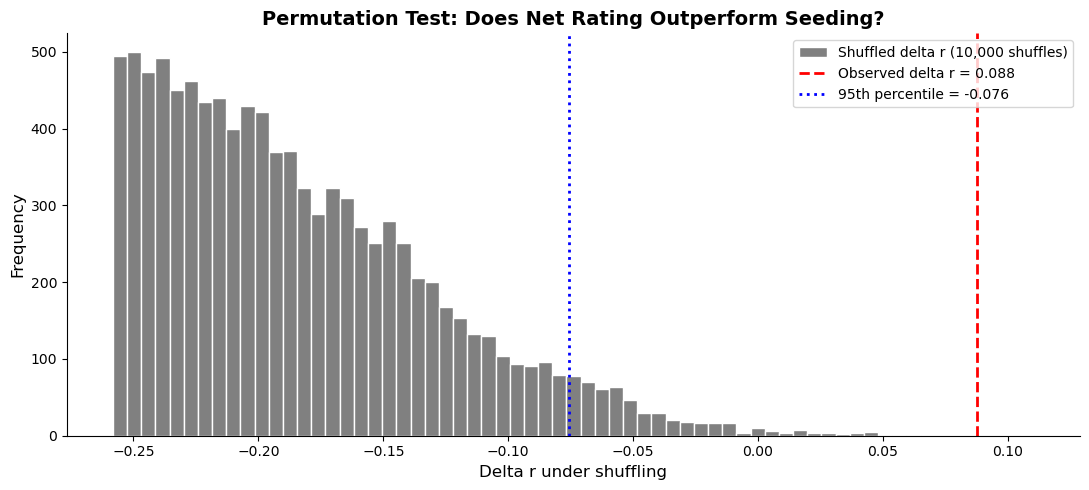

In [50]:
cutoff_95 = np.percentile(perm_deltas, 95)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(perm_deltas, bins=65, color=NBA_GREY, edgecolor='white',
        label='Shuffled delta r (10,000 shuffles)')
ax.axvline(observed_delta, color=NBA_RED, linewidth=2, linestyle='--',
           label=f'Observed delta r = {observed_delta:.3f}')
ax.axvline(cutoff_95, color=NBA_BLUE, linewidth=2, linestyle=':',
           label=f'95th percentile = {cutoff_95:.3f}')
ax.set_title('Permutation Test: Does Net Rating Outperform Seeding?', fontweight='bold')
ax.set_xlabel('Delta r under shuffling')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

---
### 5.2 Bootstrap Confidence Intervals

**Approach:** Resample the dataset (with replacement) 10,000 times. Each sample yields a Pearson r for both predictors. The resulting distributions estimate sampling uncertainty.

**If the 95% CI for Delta r excludes zero, net rating is reliably the stronger predictor.**

In [51]:
np.random.seed(42)
N_BOOT = 10_000
n = len(df)

boot_r_net  = []
boot_r_seed = []

for i in range(N_BOOT):
    idx = np.random.randint(0, n, n)
    r_net_boot, _  = stats.pearsonr(net_gaps[idx],  games[idx])
    r_seed_boot, _ = stats.pearsonr(seed_gaps[idx], games[idx])
    boot_r_net.append(r_net_boot)
    boot_r_seed.append(r_seed_boot)

boot_r_net  = np.array(boot_r_net)
boot_r_seed = np.array(boot_r_seed)
boot_delta  = np.abs(boot_r_net) - np.abs(boot_r_seed)

ci_net   = np.percentile(boot_r_net,  [2.5, 97.5])
ci_seed  = np.percentile(boot_r_seed, [2.5, 97.5])
ci_delta = np.percentile(boot_delta,  [2.5, 97.5])

print(f'Net Rating Gap  r = {r_net:.3f}   95% CI [{ci_net[0]:.3f}, {ci_net[1]:.3f}]')
print(f'Seed Gap        r = {r_seed:.3f}   95% CI [{ci_seed[0]:.3f}, {ci_seed[1]:.3f}]')
print(f'Delta r         = {observed_delta:.3f}   95% CI [{ci_delta[0]:.3f}, {ci_delta[1]:.3f}]')
print(f'CI excludes zero? {"YES" if ci_delta[0] > 0 else "NO"}')

Net Rating Gap  r = -0.346   95% CI [-0.482, -0.194]
Seed Gap        r = -0.258   95% CI [-0.411, -0.097]
Delta r         = 0.088   95% CI [-0.046, 0.221]
CI excludes zero? NO


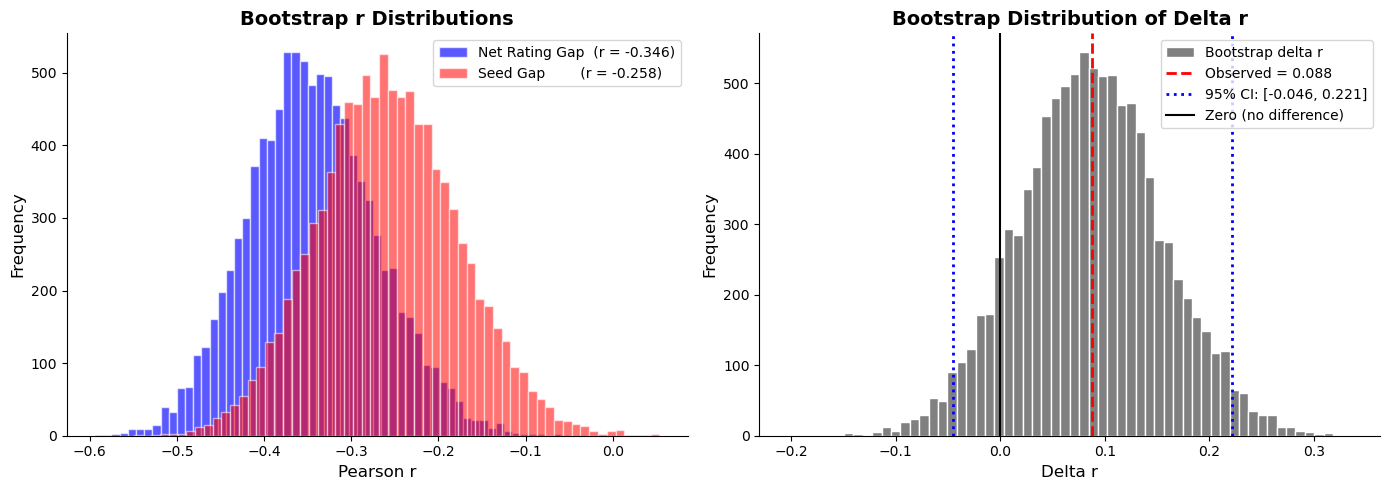

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bootstrap r distributions for each predictor
axes[0].hist(boot_r_net,  bins=60, color=NBA_BLUE, alpha=0.65, edgecolor='white',
             label=f'Net Rating Gap  (r = {r_net:.3f})')
axes[0].hist(boot_r_seed, bins=60, color=NBA_RED,  alpha=0.55, edgecolor='white',
             label=f'Seed Gap        (r = {r_seed:.3f})')
axes[0].set_title('Bootstrap r Distributions', fontweight='bold')
axes[0].set_xlabel('Pearson r')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Right: bootstrap delta r with CI bounds and zero line
axes[1].hist(boot_delta, bins=60, color=NBA_GREY, edgecolor='white',
             label='Bootstrap delta r')
axes[1].axvline(observed_delta, color=NBA_RED, linewidth=2, linestyle='--',
                label=f'Observed = {observed_delta:.3f}')
axes[1].axvline(ci_delta[0], color=NBA_BLUE, linewidth=2, linestyle=':',
                label=f'95% CI: [{ci_delta[0]:.3f}, {ci_delta[1]:.3f}]')
axes[1].axvline(ci_delta[1], color=NBA_BLUE, linewidth=2, linestyle=':')
axes[1].axvline(0, color='black', linewidth=1.5, label='Zero (no difference)')
axes[1].set_title('Bootstrap Distribution of Delta r', fontweight='bold')
axes[1].set_xlabel('Delta r')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. Case Studies — The 2026 Playoffs

All four current second-round series mapped onto the historical model.

In [53]:
current_2026 = pd.DataFrame({
    'series':     ['OKC vs LAL','SAS vs MIN','DET vs CLE','NYK vs PHI'],
    'net_rtg_a':  [12.0, 8.4, 8.0, 5.8],
    'net_rtg_b':  [3.1,  4.2, 2.8, 1.4],
    'seed_a':     [1,    2,   1,   3],
    'seed_b':     [4,    6,   4,   7],
    'actual':     ['3-0 (sweep)','2-2 (tied)','2-1 (ongoing)','4-0 (swept)'],
})
current_2026['net_rtg_gap'] = (current_2026['net_rtg_a'] - current_2026['net_rtg_b']).abs()
current_2026['seed_gap']    = (current_2026['seed_a'] - current_2026['seed_b']).abs()

slope, intercept = np.polyfit(df['net_rtg_gap'], df['games_played'], 1)
current_2026['predicted_games'] = (
    slope * current_2026['net_rtg_gap'] + intercept).clip(4,7).round(1)

current_2026[['series','net_rtg_gap','seed_gap','predicted_games','actual']]

,series,net_rtg_gap,seed_gap,predicted_games,actual
0,OKC vs LAL,8.9,3,4.9,3-0 (sweep)
1,SAS vs MIN,4.2,4,5.5,2-2 (tied)
2,DET vs CLE,5.2,3,5.4,2-1 (ongoing)
3,NYK vs PHI,4.4,4,5.5,4-0 (swept)


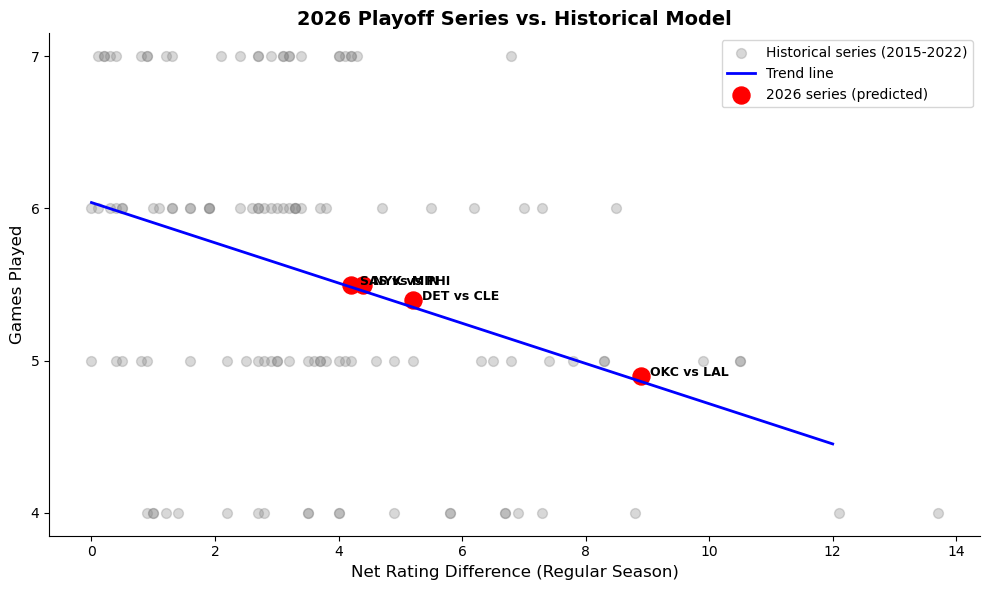

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

# Historical series
ax.scatter(df['net_rtg_gap'], df['games_played'],
           alpha=0.3, color='grey', s=50, label='Historical series (2015-2022)')

# Trend line: just two end points is enough to draw a straight line
x_line = [0, 12]
y_line = [slope * 0 + intercept, slope * 12 + intercept]
ax.plot(x_line, y_line, color='blue', linewidth=2, label='Trend line')

# 2026 series
ax.scatter(current_2026['net_rtg_gap'], current_2026['predicted_games'],
           color='red', s=150, label='2026 series (predicted)')

# Label each 2026 series
for i in range(len(current_2026)):
    ax.text(current_2026['net_rtg_gap'].iloc[i] + 0.15,
            current_2026['predicted_games'].iloc[i],
            current_2026['series'].iloc[i],
            fontsize=9, fontweight='bold')

ax.set_title('2026 Playoff Series vs. Historical Model', fontweight='bold')
ax.set_xlabel('Net Rating Difference (Regular Season)')
ax.set_ylabel('Games Played')
ax.set_yticks([4, 5, 6, 7])
ax.legend()
plt.tight_layout()
plt.show()

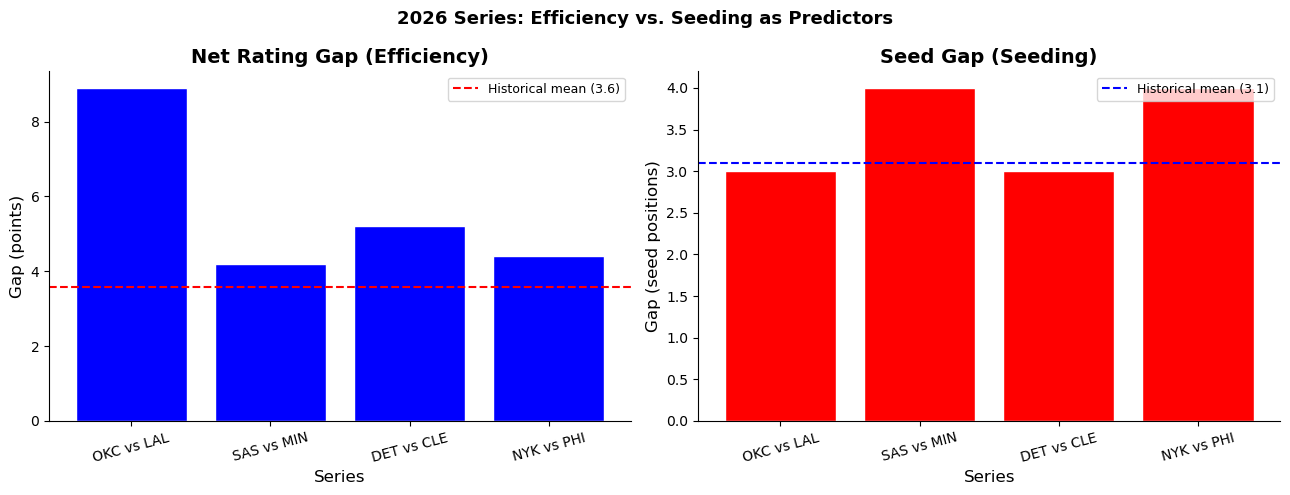

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(current_2026['series'], current_2026['net_rtg_gap'], color=NBA_BLUE, edgecolor='white')
axes[0].axhline(df['net_rtg_gap'].mean(), color=NBA_RED, linewidth=1.5, linestyle='--',
                label=f'Historical mean ({df["net_rtg_gap"].mean():.1f})')
axes[0].set_title('Net Rating Gap (Efficiency)', fontweight='bold')
axes[0].set_xlabel('Series')
axes[0].set_ylabel('Gap (points)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=9)

axes[1].bar(current_2026['series'], current_2026['seed_gap'], color=NBA_RED, edgecolor='white')
axes[1].axhline(df['seed_gap'].mean(), color=NBA_BLUE, linewidth=1.5, linestyle='--',
                label=f'Historical mean ({df["seed_gap"].mean():.1f})')
axes[1].set_title('Seed Gap (Seeding)', fontweight='bold')
axes[1].set_xlabel('Series')
axes[1].set_ylabel('Gap (seed positions)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(fontsize=9)

plt.suptitle('2026 Series: Efficiency vs. Seeding as Predictors', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Conclusions

In [ ]:
print('=' * 60)
print('  RESULTS SUMMARY')
print('=' * 60)
print(f'  Dataset:  {len(df)} series | 2015-2022 | 8 seasons')
print(f'  Net Rating Gap  r = {r_net:.3f}   p = {p_net:.4f}')
print(f'  Seed Gap        r = {r_seed:.3f}   p = {p_seed:.4f}')
print(f'  Observed delta r   = {abs(r_net)-abs(r_seed):.4f}')
print()
print(f'  Permutation p-value    = {p_value:.4f}')
print(f'  Bootstrap 95% CI       = [{ci_delta[0]:.3f}, {ci_delta[1]:.3f}]')
print(f'  CI excludes zero?       {"YES" if ci_delta[0] > 0 else "NO"}')
print('=' * 60)
if p_value < 0.05:
    print('  REJECT H0. Net rating gap is a significantly stronger')
    print('  predictor of series competitiveness than seeding alone.')
else:
    print('  FAIL TO REJECT H0 at alpha=0.05.')
print('=' * 60)
print()
print('2026 CASE STUDY VERDICTS:')
print('  OKC/LAL  gap=8.9 - sweep predicted')
print('  SAS/MIN  gap=4.2 - competitive predicted')
print('  DET/CLE  gap=5.2 - moderate predicted')
print('  NYK/PHI  gap=4.4 - predicted 6 games; actual sweep (best outlier for discussion)')

---
## 8. Limitations & Scope of Inference

- **Observational data.** No causal claims — injuries, coaching, and matchup factors not captured.
- **Seed derivation is a proxy.** Derived by ranking within conference by wins, not official tiebreaker rules or play-in placement.
- **Dataset window: 2015–2022.** Missing 2023–2025 due to `game.csv` coverage cutoff.
- **Net rating reflects regular-season opponents** — inflated ratings may not survive playoff competition.

---
*Herbert Ouma | herbertouma@gmail.com | linkedin.com/in/herbertoumajr | M.S. Data Science, University of St. Thomas | May 2026*